# Ulusal Faktoring — Check Default: Model

Builds on `EDA.ipynb`.

Steps: 1) prepare & split · 2) scorecard · 3) LightGBM · 4) imbalance test · 5) calibration · 6) test results · 7) business view · 8) SHAP · 9) conclusions

In [1]:
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression

from helpers import WoEEncoder, bootstrap_ci, calibration_table, cutoff_table, gini, metrics

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")

FIG_DIR = Path("figures/model")
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)
SEED = 42


def save(name):
    plt.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

## 1. Prepare & split
`prepare()` applies the cleaning rules from the EDA. It works row by row, so the same function can score a single new check. I don't cap outliers, since neither model is sensitive to them.

In [2]:
SEGMENTS = ["A", "B", "C", "D"]


def prepare(raw):
    df = raw.drop(columns=["Unnamed: 0", "TERM"], errors="ignore").rename(
        columns={"founder age": "founder_age", "company age": "company_age"})
    df["issue_month"] = pd.to_datetime(df["term"].astype(str), format="%Y%m")

    # Cleaning rules (EDA §4)
    df.loc[df["days_due"] < 0, "days_due"] = np.nan                                       # due before issue: data error
    df.loc[df["drawer_creditbureauscore"] == 0, "drawer_creditbureauscore"] = np.nan      # 0 = "no score" code

    # founder_age / company_age stay separate: exactly one is present per check (micro vs company, EDA §3),
    # so their missing pattern already tells the model which type of business it is.
    df["branch_segment"] = pd.Categorical(df["branch_segment"], categories=SEGMENTS)
    return df


def assign_split(issue_month):
    # EDA §2.1 / §7: issue months >= 2025-06 are incomplete cohorts (only short-term checks had matured).
    return np.select([issue_month < "2024-01-01", issue_month < "2024-07-01", issue_month < "2025-06-01"],
                     ["train", "valid", "test"], "excluded")


df = prepare(pd.read_excel("UF_DS_case.xlsx"))
df["split"] = assign_split(df["issue_month"])

split_summary = df.groupby("split").agg(
    first_month=("issue_month", "min"), last_month=("issue_month", "max"),
    n=("target", "size"), defaults=("target", "sum"), default_rate=("target", "mean"),
).loc[["train", "valid", "test", "excluded"]]
split_summary.assign(first_month=lambda t: t.first_month.dt.strftime("%Y-%m"),
                     last_month=lambda t: t.last_month.dt.strftime("%Y-%m"),
                     default_rate=lambda t: (t.default_rate * 100).round(2))

,first_month,last_month,n,defaults,default_rate
split,,,,,
train,2020-01,2023-12,61500,2683,4.36
valid,2024-01,2024-06,11366,1000,8.80
test,2024-07,2025-05,23414,1939,8.28
excluded,2025-06,2025-10,3720,247,6.64


In [3]:
FEATURES = ["amount", "days_due", "cust_tenure", "company_age", "founder_age",
            "drawer_creditbureauscore", "drawer_last_redflag_date", "drawer_unpaidcheckcount",
            "drawer_interest_accumulated", "branch_segment"]

train, valid, test = (df[df["split"] == s].copy() for s in ["train", "valid", "test"])
y_tr, y_va, y_te = train["target"], valid["target"], test["target"]
print({k: v.shape for k, v in {"train": train, "valid": valid, "test": test}.items()})

{'train': (61500, 20), 'valid': (11366, 20), 'test': (23414, 20)}


**Features**
- Kept: amount, `days_due`, tenure, credit score, company age, founder age, red-flag date, unpaid count.
- Being tested: segment and interest accumulated (unstable in the EDA).
- Dropped: `TERM`/date, first-offer flag, late balance, unpaid ratio, other-factoring risk, max balance (no signal and/or drift).

I keep company and founder age separate. A combined age column scored the same, but it treated a 40-year-old founder like a 40-year-old company, which made the explanations confusing.

## 2. Scorecard (baseline)
A simple and transparent benchmark:
1. bin each feature (5 bins + Missing);
2. replace each bin with its WoE;
3. keep features with IV ≥ 0.02;
4. fit a logistic regression;
5. convert it to points (600 = 50:1 odds of paying, +20 points doubles the odds).

In [4]:
SC_CANDIDATES = FEATURES
custom_edges = {
    "drawer_last_redflag_date": np.array([-np.inf, 30, 90, np.inf]),
    "drawer_unpaidcheckcount": np.array([-np.inf, 0, np.inf]),
}
woe = WoEEncoder(q=5, custom_edges=custom_edges).fit(train[SC_CANDIDATES], y_tr)
iv_train = woe.iv()
SC_FEATURES = iv_train[iv_train >= 0.02].index.tolist()
print("Train IV:\n", iv_train.round(3).to_string())
print("\nScorecard features (IV >= 0.02):", SC_FEATURES)

Train IV:
 amount                         0.122
drawer_creditbureauscore       0.113
drawer_unpaidcheckcount        0.078
drawer_last_redflag_date       0.054
cust_tenure                    0.047
company_age                    0.042
days_due                       0.041
branch_segment                 0.018
drawer_interest_accumulated    0.012
founder_age                    0.008

Scorecard features (IV >= 0.02): ['amount', 'drawer_creditbureauscore', 'drawer_unpaidcheckcount', 'drawer_last_redflag_date', 'cust_tenure', 'company_age', 'days_due']


In [5]:
def fit_scorecard(features):
    lr = LogisticRegression(C=1.0, max_iter=2000)
    lr.fit(woe.transform(train[features]), y_tr)
    return lr


# WoE = ln(%good / %bad), so every coefficient should be NEGATIVE (higher WoE = safer = lower PD).
# A positive sign means the feature is fighting a correlated one; drop it and refit.
sc_features = list(SC_FEATURES)
while True:
    scorecard = fit_scorecard(sc_features)
    coefs = pd.Series(scorecard.coef_[0], index=sc_features)
    if (coefs < 0).all():
        break
    sc_features.remove(coefs.idxmax())
print(coefs.round(3).to_string())

p_sc = {name: scorecard.predict_proba(woe.transform(d[sc_features]))[:, 1]
        for name, d in {"train": train, "valid": valid, "test": test}.items()}
print(f"\nScorecard Gini — train: {gini(y_tr, p_sc['train']):.1%}   valid: {gini(y_va, p_sc['valid']):.1%}")

amount                     -0.917
drawer_creditbureauscore   -0.956
drawer_unpaidcheckcount    -0.803
drawer_last_redflag_date   -0.770
cust_tenure                -0.734
company_age                -0.568
days_due                   -0.927



Scorecard Gini — train: 33.7%   valid: 32.2%


In [6]:
PDO, BASE_SCORE, BASE_ODDS = 20, 600, 50
factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)
k = len(sc_features)

rows = []
for c, b in zip(sc_features, coefs.values):
    t = woe.tables[c]
    for bin_label, r in t.iterrows():
        # Score = offset + factor * ln(odds of paying) = sum over features of the points below
        points = -(b * r["woe"] + scorecard.intercept_[0] / k) * factor + offset / k
        rows.append({"feature": c, "bin": bin_label, "n_train": int(r["n"]),
                     "default_rate_%": r["default_rate"] * 100, "woe": r["woe"], "points": round(points)})
points_table = pd.DataFrame(rows)
points_table.to_csv(MODEL_DIR / "scorecard_points.csv", index=False)
points_table.set_index(["feature", "bin"]).round(2)

n_train  default_rate_%   woe  points
feature                  bin                                                          
amount                   (-inf, 467211.429]        12300            2.19  0.71     101
                         (467211.429, 800000.0]    12739            3.60  0.20      88
                         (800000.0, 1250000.0]     12737            4.56 -0.05      81
                         (1250000.0, 2087500.0]    11427            5.98 -0.33      74
                         (2087500.0, inf]          12297            5.62 -0.27      75
drawer_creditbureauscore (-inf, 1246.0]             2950            9.05 -0.78      61
                         (1246.0, 1410.0]           2942            4.38 -0.01      82
                         (1410.0, 1553.0]           2954            2.27  0.67     101
                         (1553.0, 1704.0]           2945            2.38  0.62      99
                         (1704.0, inf]              2933            1.36  1.18     115
                         Missing                   46776            4.51 -0.03      81
drawer_unpaidcheckcount  (-inf, 0.0]               60555            4.28  0.02      83
                         (0.0, inf]                  200           38.50 -2.62      22
                         Missing                     745            1.61  0.99     105
drawer_last_redflag_date (-inf, 30.0]                133           39.85 -2.68      23
                         (30.0, 90.0]                 60           15.00 -1.40      51
                         (90.0, inf]                1001            4.00  0.08      84
                         Missing                   60306            4.28  0.02      83
cust_tenure              (-inf, 206.0]             12313            5.73 -0.29      76
                         (206.0, 563.0]            12300            4.83 -0.11      80
                         (563.0, 1086.0]           12299            4.32  0.01      83
                         (1086.0, 1878.0]          12291            3.88  0.12      85
                         (1878.0, inf]             12297            3.05  0.37      90
company_age              (-inf, 2.0]               12085            5.63 -0.27      78
                         (2.0, 4.0]                 9263            4.96 -0.13      80
                         (4.0, 6.0]                 6156            4.47 -0.03      82
                         (6.0, 12.0]                8359            3.96  0.10      84
                         (12.0, inf]                8932            2.96  0.40      89
                         Missing                   16705            4.03  0.08      84
days_due                 (-inf, 62.0]              12556            3.27  0.30      90
                         (62.0, 89.0]              12129            4.49 -0.03      81
                         (89.0, 115.0]             12627            5.23 -0.19      77
                         (115.0, 148.0]            11952            5.29 -0.20      77
                         (148.0, inf]              12230            3.56  0.21      88
                         Missing                       6            0.00 -0.52      68

Score = sum of points; higher is safer. For example, a credit score above 1,704 gets 115 points vs 61 for one below 1,246. An unpaid check at the drawer gives 22 instead of 83.

7 features pass the IV filter, and all coefficients are negative as expected. Gini is 33.7% on train and 32.2% on validation, so there's no overfitting.

(The `days_due` Missing bin holds only 6 data-error rows; in practice I'd reject those checks rather than score them.)

## 3. LightGBM
- Monotonic constraints follow the EDA: amount and unpaid count ↑ risk; credit score, tenure, ages and red-flag age ↓ risk.
- NaN is left as it is.
- No tuning: conservative settings plus early stopping on validation.

In [7]:
MONOTONE = {"amount": 1, "cust_tenure": -1, "company_age": -1, "founder_age": -1, "drawer_creditbureauscore": -1,
            "drawer_last_redflag_date": -1, "drawer_unpaidcheckcount": 1}

BASE_PARAMS = dict(objective="binary", metric="auc", learning_rate=0.03, num_leaves=15, min_child_samples=200,
                   feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=1, lambda_l2=5.0,
                   monotone_constraints_method="advanced", verbose=-1, seed=SEED)


def fit_lgbm(features, train_df=None, extra_params=None):
    train_df = train if train_df is None else train_df
    params = {**BASE_PARAMS, **(extra_params or {}),
              "monotone_constraints": [MONOTONE.get(f, 0) for f in features]}
    dtrain = lgb.Dataset(train_df[features], train_df["target"])
    dvalid = lgb.Dataset(valid[features], y_va, reference=dtrain)
    return lgb.train(params, dtrain, num_boost_round=3000, valid_sets=[dvalid],
                     callbacks=[lgb.early_stopping(150, verbose=False)])

**Do segment and interest accumulated help?** Rule: keep the simpler model unless a feature adds more than 1 Gini point (validation noise is about ±4).

In [8]:
UNSTABLE = ["branch_segment", "drawer_interest_accumulated"]
options = {
    "all features": FEATURES,
    "without branch_segment": [f for f in FEATURES if f != "branch_segment"],
    "without interest_accumulated": [f for f in FEATURES if f != "drawer_interest_accumulated"],
    "without both": [f for f in FEATURES if f not in UNSTABLE],
}
drop_check = []
for name, feats in options.items():
    m = fit_lgbm(feats)
    drop_check.append({"option": name, "n_features": len(feats), "best_iteration": m.best_iteration,
                       "valid_gini_%": gini(y_va, m.predict(valid[feats], num_iteration=m.best_iteration)) * 100})
drop_check = pd.DataFrame(drop_check).set_index("option")

best = drop_check["valid_gini_%"].max()
eligible = drop_check[drop_check["valid_gini_%"] >= best - 1.0]
chosen = eligible.sort_values(["n_features", "valid_gini_%"], ascending=[True, False]).index[0]
LGB_FEATURES = options[chosen]
print(drop_check.round(2))
print(f"\nChosen: {chosen}  ->  {LGB_FEATURES}")

                              n_features  best_iteration  valid_gini_%
option                                                                
all features                          10              96         32.74
without branch_segment                 9              99         32.95
without interest_accumulated           9              96         32.86
without both                           8             170         32.95

Chosen: without both  ->  ['amount', 'days_due', 'cust_tenure', 'company_age', 'founder_age', 'drawer_creditbureauscore', 'drawer_last_redflag_date', 'drawer_unpaidcheckcount']


In [9]:
lgbm = fit_lgbm(LGB_FEATURES)
p_lgb = {name: lgbm.predict(d[LGB_FEATURES], num_iteration=lgbm.best_iteration)
         for name, d in {"train": train, "valid": valid, "test": test}.items()}
lgbm.save_model(str(MODEL_DIR / "lgbm_model.txt"), num_iteration=lgbm.best_iteration)

print(f"Best iteration: {lgbm.best_iteration}")
print(f"LightGBM Gini — train: {gini(y_tr, p_lgb['train']):.1%}   valid: {gini(y_va, p_lgb['valid']):.1%}")
print(f"Scorecard Gini — train: {gini(y_tr, p_sc['train']):.1%}   valid: {gini(y_va, p_sc['valid']):.1%}")

Best iteration: 170
LightGBM Gini — train: 39.6%   valid: 32.9%
Scorecard Gini — train: 33.7%   valid: 32.2%


All four options are within 0.2 points of each other, so I drop both features (8 features left).

Validation Gini: LightGBM 32.9% vs scorecard 32.2%. Very close, which matches the EDA (weak, monotonic, uncorrelated signals).

## 4. Imbalance test
Same model trained three ways: as is · with class weights · with defaults upsampled to 50/50 (train only).

In [10]:
n_pos, n_neg = int(y_tr.sum()), int((1 - y_tr).sum())
upsampled = pd.concat([train[y_tr == 0], train[y_tr == 1].sample(n_neg, replace=True, random_state=SEED)])

configs = {
    "none": dict(train_df=train),
    "class weights": dict(train_df=train, extra_params={"scale_pos_weight": n_neg / n_pos}),
    "upsampling 50/50": dict(train_df=upsampled),
}
imb_rows, imb_preds = [], {}
for name, kw in configs.items():
    m = fit_lgbm(LGB_FEATURES, **kw)
    p = m.predict(valid[LGB_FEATURES], num_iteration=m.best_iteration)
    imb_preds[name] = p
    r = metrics(y_va, p)
    imb_rows.append({"config": name, "best_iteration": m.best_iteration, "valid_gini_%": r["gini"] * 100,
                     "brier": r["brier"], "mean_predicted_pd_%": r["mean_pd"] * 100,
                     "actual_default_rate_%": r["default_rate"] * 100})
imbalance = pd.DataFrame(imb_rows).set_index("config")
imbalance.round(4)

,best_iteration,valid_gini_%,brier,mean_predicted_pd_%,actual_default_rate_%
config,,,,,
none,170,32.9469,0.0798,4.5957,8.7982
class weights,146,32.9161,0.2244,45.6605,8.7982
upsampling 50/50,199,32.7438,0.2260,45.8888,8.7982


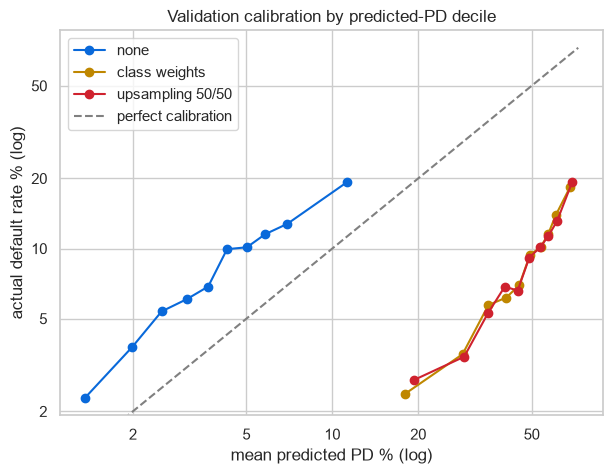

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
for (name, p), color in zip(imb_preds.items(), ["#0969da", "#bf8700", "#cf222e"]):
    ct = calibration_table(y_va, p)
    ax.plot(ct["mean_pd"] * 100, ct["default_rate"] * 100, marker="o", label=name, color=color)
lim = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([0, lim], [0, lim], ls="--", color="grey", label="perfect calibration")
ax.set(xscale="log", yscale="log", xlabel="mean predicted PD % (log)", ylabel="actual default rate % (log)",
       title="Validation calibration by predicted-PD decile")
for axis in (ax.xaxis, ax.yaxis):
    axis.set_major_locator(mtick.FixedLocator([1, 2, 5, 10, 20, 50]))
    axis.set_major_formatter(mtick.FormatStrFormatter("%g"))
    axis.set_minor_formatter(mtick.NullFormatter())
ax.legend()
save("01_imbalance_calibration")
plt.show()

- Gini is the same for all three (about 33%).
- With weights or upsampling, the average predicted PD jumps to about 46% when the actual rate is 8.8%, and the Brier score triples.

So re-balancing doesn't help. I train on the data as it is, and I handle the imbalance through the cut-off choice. (The "none" model also under-predicts; that's the time drift, fixed in the next step.)

## 5. Calibration
The model learned a 4.4% default rate, but recent rates are about 8–9%. I recalibrate with Platt scaling on the validation period. This doesn't change the ranking (Gini), only the PD level.

In [12]:
def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))


def fit_platt(p_valid, y_valid):
    cal = LogisticRegression(C=1e6, max_iter=1000).fit(logit(p_valid).reshape(-1, 1), y_valid)
    return lambda p: cal.predict_proba(logit(p).reshape(-1, 1))[:, 1]


cal_lgb = fit_platt(p_lgb["valid"], y_va)
cal_sc = fit_platt(p_sc["valid"], y_va)
pd_lgb_te, pd_sc_te = cal_lgb(p_lgb["test"]), cal_sc(p_sc["test"])

calib_summary = pd.DataFrame({
    "LightGBM raw": metrics(y_te, p_lgb["test"]), "LightGBM calibrated": metrics(y_te, pd_lgb_te),
    "Scorecard raw": metrics(y_te, p_sc["test"]), "Scorecard calibrated": metrics(y_te, pd_sc_te),
}).T[["mean_pd", "default_rate", "brier", "gini"]]
calib_summary.assign(mean_pd=lambda t: t.mean_pd * 100, default_rate=lambda t: t.default_rate * 100,
                     gini=lambda t: t.gini * 100).rename(columns={"mean_pd": "mean_pd_%", "default_rate": "actual_%",
                                                                   "gini": "gini_%"}).round(4)

,mean_pd_%,actual_%,brier,gini_%
LightGBM raw,4.8583,8.2814,0.0748,33.2067
LightGBM calibrated,9.2136,8.2814,0.0735,33.2067
Scorecard raw,4.8240,8.2814,0.0750,31.9673
Scorecard calibrated,9.1402,8.2814,0.0737,31.9673


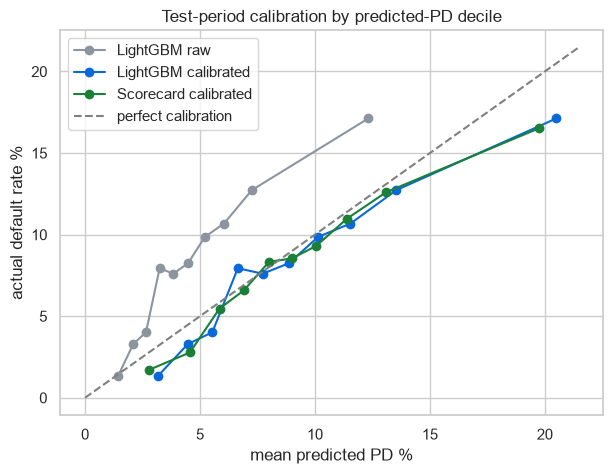

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
for p, label, color in [(p_lgb["test"], "LightGBM raw", "#8c959f"), (pd_lgb_te, "LightGBM calibrated", "#0969da"),
                        (pd_sc_te, "Scorecard calibrated", "#1a7f37")]:
    ct = calibration_table(y_te, p)
    ax.plot(ct["mean_pd"] * 100, ct["default_rate"] * 100, marker="o", label=label, color=color)
lim = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([0, lim], [0, lim], ls="--", color="grey", label="perfect calibration")
ax.set(xlabel="mean predicted PD %", ylabel="actual default rate %", title="Test-period calibration by predicted-PD decile")
ax.legend()
save("02_calibration_test")
plt.show()

- Raw PD averages 4.9% vs 8.3% actual; calibrated, it's 9.2% vs 8.3% (slightly conservative).
- The Brier score improves and the curve follows the diagonal.
- In production, recalibration should be repeated regularly.

## 6. Test results (2024-07 → 2025-05)
Run once, at the end. The confidence intervals come from bootstrapping.

In [14]:
test_metrics = pd.DataFrame({"Scorecard": metrics(y_te, pd_sc_te), "LightGBM": metrics(y_te, pd_lgb_te)}).T
test_metrics[["gini", "ks", "pr_auc"]] *= 100
print(test_metrics.rename(columns={"gini": "gini_%", "ks": "ks_%", "pr_auc": "pr_auc_%"}).round(3).to_string())
print(f"\n(PR-AUC of a random model = default rate = {y_te.mean():.1%})\n")

ci = bootstrap_ci(y_te, {"Scorecard": pd_sc_te, "LightGBM": pd_lgb_te}, n_boot=500, seed=SEED) * 100
ci.round(2)

           gini_%    ks_%  pr_auc_%  brier  mean_pd  default_rate
Scorecard  31.967  22.465    15.629  0.074    0.091         0.083
LightGBM   33.207  23.823    16.066  0.074    0.092         0.083

(PR-AUC of a random model = default rate = 8.3%)



,gini,ci_low,ci_high
model,,,
Scorecard,31.97,29.78,34.38
LightGBM,33.21,30.87,35.39
LightGBM - Scorecard,1.24,0.28,2.05


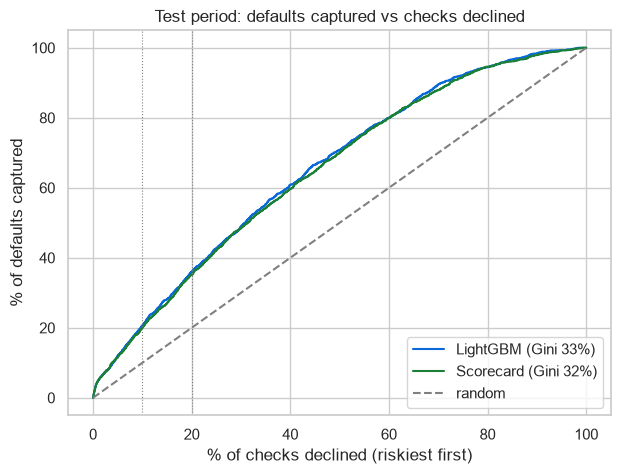

In [15]:
def capture_curve(y, p):
    order = np.argsort(-np.asarray(p))
    y = np.asarray(y)[order]
    return np.arange(1, len(y) + 1) / len(y), np.cumsum(y) / y.sum()


fig, ax = plt.subplots(figsize=(7, 5))
for p, label, color in [(pd_lgb_te, "LightGBM", "#0969da"), (pd_sc_te, "Scorecard", "#1a7f37")]:
    x, c = capture_curve(y_te, p)
    ax.plot(x * 100, c * 100, label=f"{label} (Gini {gini(y_te, p):.0%})", color=color)
ax.plot([0, 100], [0, 100], ls="--", color="grey", label="random")
for r in [10, 20]:
    ax.axvline(r, ls=":", color="grey", lw=.8)
ax.set(xlabel="% of checks declined (riskiest first)", ylabel="% of defaults captured",
       title="Test period: defaults captured vs checks declined")
ax.legend(loc="lower right")
save("03_capture_curve")
plt.show()

In [16]:
seg_rows = []
for s, g in test.assign(p_lgb=pd_lgb_te, p_sc=pd_sc_te).groupby("branch_segment", observed=True):
    seg_rows.append({"segment": s, "n": len(g), "defaults": int(g["target"].sum()),
                     "default_rate_%": g["target"].mean() * 100, "mean_pd_%": g["p_lgb"].mean() * 100,
                     "gini_lgbm_%": gini(g["target"], g["p_lgb"]) * 100,
                     "gini_scorecard_%": gini(g["target"], g["p_sc"]) * 100})
by_segment = pd.DataFrame(seg_rows).set_index("segment")
by_segment.round(2)

,n,defaults,default_rate_%,mean_pd_%,gini_lgbm_%,gini_scorecard_%
segment,,,,,,
A,11894,973,8.18,8.85,32.48,31.64
B,1005,110,10.95,9.91,38.16,40.47
C,4147,310,7.48,9.38,32.05,31.53
D,6368,546,8.57,9.68,33.94,30.87


- LightGBM: Gini 33.2% (30.9–35.4). Scorecard: 32.0% (29.8–34.4). Same as validation, and within the 30–40% range I expected.
- LightGBM is better by +1.2 points (0.3–2.1): a real difference, but a small one.
- PR-AUC is about 16%, 2× the random baseline (8.3%).
- It works in every segment (Gini 32–38%), including D.

## 7. Business view
Decline the riskiest X% of checks: what does that achieve?

In [17]:
cuts = cutoff_table(y_te, pd_lgb_te, test["amount"])
print(f"Baseline default rate (approve everything): {cuts.attrs['baseline_default_rate_%']:.2f}%\n")
cuts.assign(pd_cutoff=lambda t: t.pd_cutoff * 100).rename(columns={"pd_cutoff": "pd_cutoff_%"}).round(2)

Baseline default rate (approve everything): 8.28%



,pd_cutoff_%,defaults_avoided_%,defaulted_amount_avoided_%,default_rate_declined_%,default_rate_approved_%
decline_%,,,,,
5.0,16.31,12.02,13.61,19.90,7.67
10.0,14.86,20.63,23.84,17.09,7.30
15.0,13.45,28.16,32.25,15.55,7.00
20.0,12.37,36.05,41.76,14.93,6.62
30.0,10.80,48.94,54.79,13.51,6.04


**Hard rules?** Would rules on recent red flags or unpaid checks add anything?

In [18]:
risk_rank = pd.Series(pd_lgb_te, index=test.index).rank(ascending=False, pct=True)
rules = {
    "drawer red flag in last 90 days": test["drawer_last_redflag_date"] <= 90,
    "drawer has unpaid check(s)": test["drawer_unpaidcheckcount"] > 0,
}
rules["either rule"] = rules["drawer red flag in last 90 days"] | rules["drawer has unpaid check(s)"]
rule_tbl = pd.DataFrame({
    name: {"checks": int(m.sum()), "share_of_test_%": m.mean() * 100, "default_rate_%": y_te[m].mean() * 100,
           "already_in_model_top_10%_%": (risk_rank[m] <= 0.10).mean() * 100,
           "already_in_model_top_20%_%": (risk_rank[m] <= 0.20).mean() * 100}
    for name, m in rules.items()}).T
rule_tbl.round(2)

,checks,share_of_test_%,default_rate_%,already_in_model_top_10%_%,already_in_model_top_20%_%
drawer red flag in last 90 days,141.0,0.6,35.46,92.2,94.33
drawer has unpaid check(s),118.0,0.5,46.61,100.0,100.00
either rule,234.0,1.0,38.46,95.3,96.58


- Declining 10% avoids 21% of defaults and 24% of defaulted amount, and the approved book's default rate drops from 8.3% to 7.3%.
- Declining 20% avoids 36% / 42%.
- But over 80% of the declined checks would have paid, so the real cut-off needs margin and loss data.
- My suggestion: three bands: approve, manual review, decline.

The hard rules cover only 1% of checks, and the model already ranks 95% of those in its top 10%. They're fine as policy overrides, but they don't add ranking power.

## 8. SHAP
SHAP splits each prediction into feature contributions (positive = more risk). The average absolute value gives the feature importance.

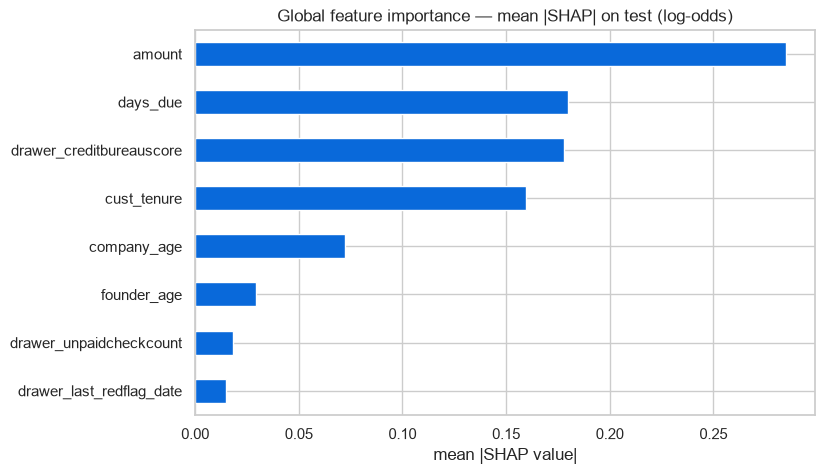

In [19]:
contrib = lgbm.predict(test[LGB_FEATURES], num_iteration=lgbm.best_iteration, pred_contrib=True)
shap_df = pd.DataFrame(contrib[:, :-1], columns=LGB_FEATURES, index=test.index)
importance = shap_df.abs().mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importance.plot.barh(ax=ax, color="#0969da")
ax.set(title="Global feature importance — mean |SHAP| on test (log-odds)", xlabel="mean |SHAP value|")
save("04_shap_importance")
plt.show()

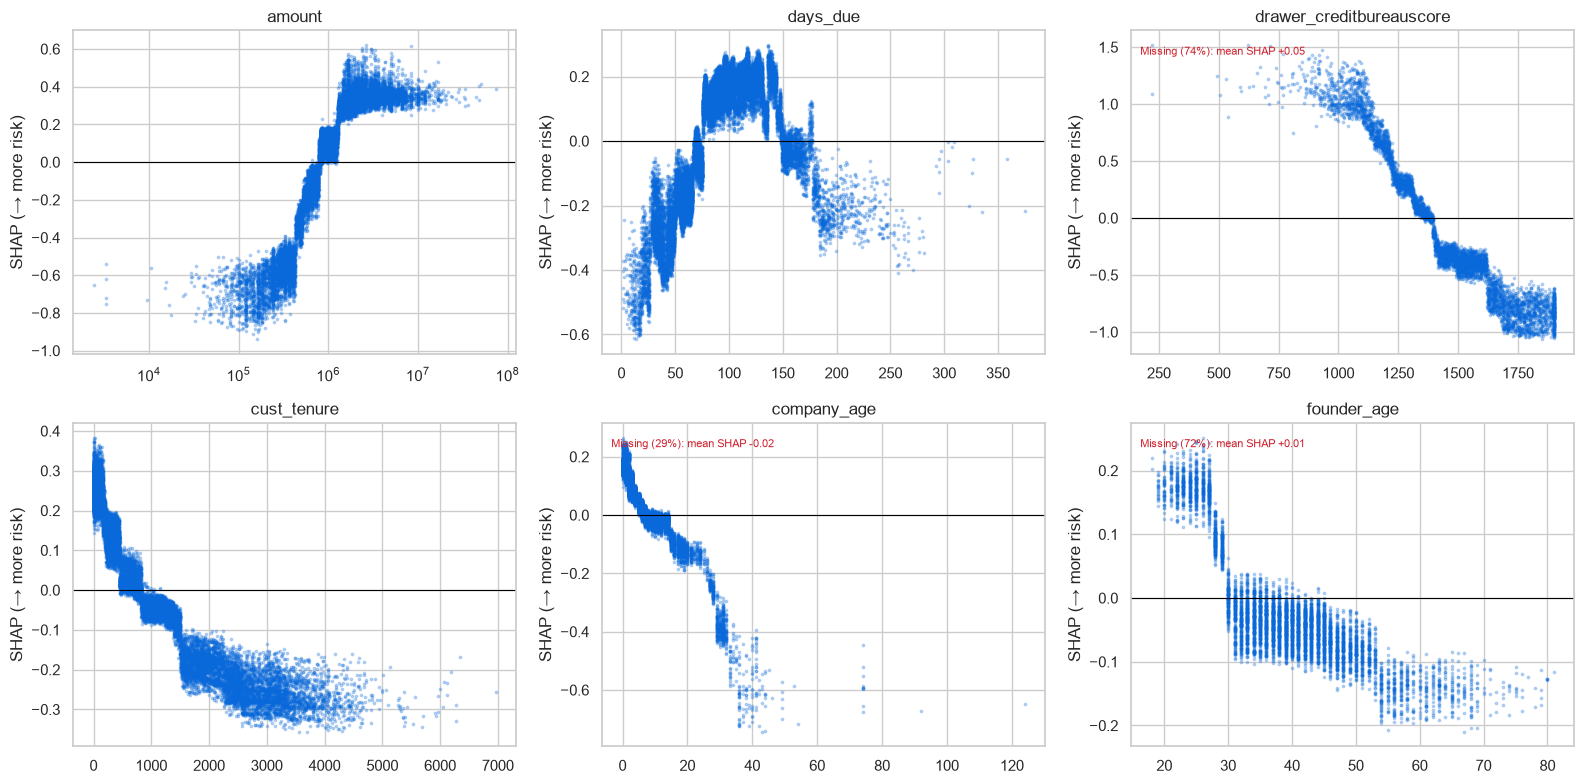

In [20]:
top = importance.index[::-1][:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, f in zip(axes.flat, top):
    x = test[f]
    if str(x.dtype) == "category":
        sns.boxplot(x=x.astype(str), y=shap_df[f], ax=ax, color="#54aeff", showfliers=False)
    else:
        miss = x.isna()
        ax.scatter(x[~miss], shap_df.loc[~miss, f], s=3, alpha=.25, color="#0969da")
        if miss.any():
            ax.text(.02, .95, f"Missing ({miss.mean():.0%}): mean SHAP {shap_df.loc[miss, f].mean():+.2f}",
                    transform=ax.transAxes, fontsize=8, va="top", color="#cf222e")
        if f in ("amount", "drawer_interest_accumulated"):
            ax.set_xscale("symlog")
    ax.axhline(0, color="black", lw=.8)
    ax.set(title=f, xlabel="", ylabel="SHAP (→ more risk)")
plt.tight_layout()
save("05_shap_dependence")
plt.show()

**Example:** the reasons behind one high-risk check.

In [21]:
order = np.argsort(-pd_lgb_te)
example_idx = test.index[order[int(0.02 * len(test))]]
ex = pd.DataFrame({"value": test.loc[example_idx, LGB_FEATURES].astype(object),
                   "shap_log_odds": shap_df.loc[example_idx]}).sort_values("shap_log_odds", ascending=False)
print(f"Check ID {test.loc[example_idx, 'ID']}  |  calibrated PD = {pd_lgb_te[order[int(0.02 * len(test))]]:.1%}  "
      f"(portfolio average {y_te.mean():.1%})  |  actual outcome: {'DEFAULT' if test.loc[example_idx, 'target'] else 'paid'}")
ex.round(3)

Check ID 68433  |  calibrated PD = 22.4%  (portfolio average 8.3%)  |  actual outcome: paid


,value,shap_log_odds
drawer_creditbureauscore,1098.0,1.058
days_due,91.0,0.148
amount,843373.493976,0.087
cust_tenure,514.0,0.058
founder_age,NaN,0.020
company_age,7.0,0.011
drawer_last_redflag_date,NaN,-0.003
drawer_unpaidcheckcount,0.0,-0.007


- Amount matters most, then `days_due`, credit score and tenure.
- Drawer history ranks low overall because it's rare, but it's strong when present.
- All the shapes match the EDA: amount ↑, credit score ↓, tenure ↓, `days_due` inverted U, ages ↓.
- The example check (PD 22%) is driven mainly by its low credit score. It actually paid: a 22% PD still means most such checks pay.

## 9. Conclusions

| Test period | Scorecard | LightGBM |
|---|---|---|
| Gini (95% CI) | 32.0% (29.8–34.4) | **33.2% (30.9–35.4)** |
| KS | 22.5% | 23.8% |
| PR-AUC (random 8.3%) | 15.6% | 16.1% |

**Recommendations**
1. Use LightGBM as the main model, and keep the scorecard as a simpler backup.
2. Use a three-band policy (approve / review / decline). Declining 10% cuts the default rate from 8.3% to 7.3%.
3. Recalibrate regularly and monitor drift, because the default rate doubled in two years.

**Limitations:** the features are weak (Gini about 33%), 75% of credit scores are missing, and some data questions are still open (amount, timing of the drawer-history features).

**Next steps:** a walk-forward backtest, time-weighted training, and a cut-off based on profit and loss data.